[1. Print keys ](#print_key)

[2. qubit_spec_with_different_LO ](#qubit_spec_with_different_LO)

[3. RR_spec_with_different_yoko ](#RR_spec_with_different_yoko)

[4. vna_flux_sweep ](#vna_flux_sweep)

[5. qubit_spec_in_flux_sweep ](#qubit_spec_in_flux_sweep)

[6. rr_spec_with_flux_and_lo ](#rr_spec_with_flux_and_lo) 

[7. qubit_spec_in_flux_sweep_with_filter_data_with_mean ](#qubit_spec_in_flux_sweep_with_filter_data_with_mean) 

[8. qubit_spec_with_flux_and_lo ](#qubit_spec_with_flux_and_lo) 

env: qcrew

## rr_spec with flux and lo
<a id="rr_spec_with_flux_and_lo"></a>

Processing 21 total files...


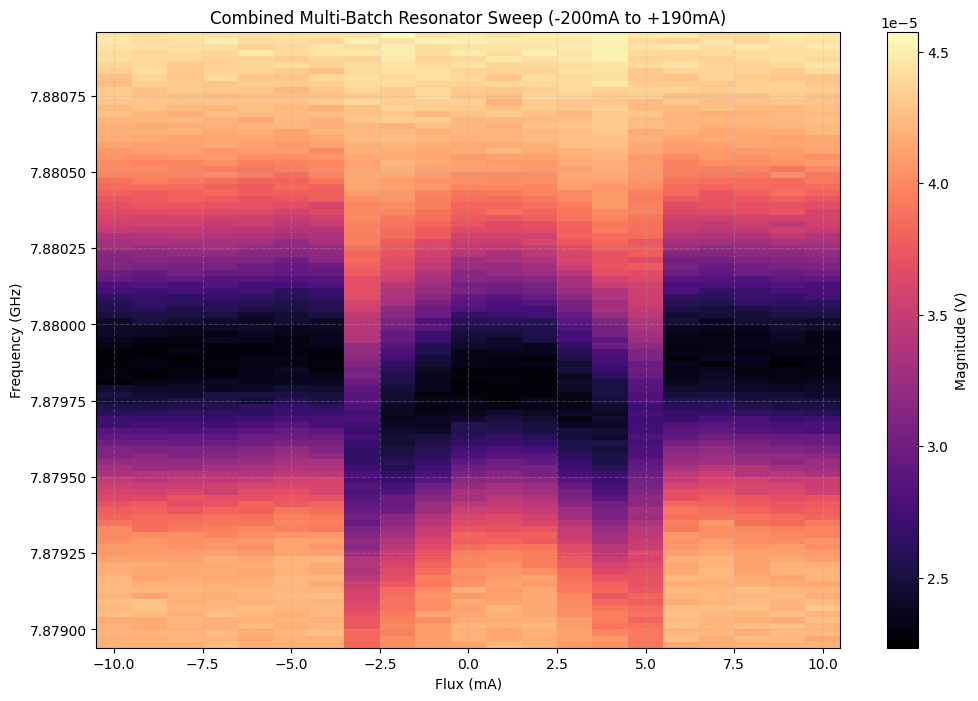

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# --- Define all batches in a list for easy management ---
batches = [
    {
        "folder": "C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-06-10/",
        "time": ((18, 11), (18, 20)),
        "flux": np.linspace(start=-10e-3, stop=10e-3, num=21) #np.arange(0e-3, 100e-3 + 10e-3, 10e-3)
        # flux_values = np.linspace(start=-10e-3, stop=10e-3, num=21)
    },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 35), (16, 40)),
    #     "flux": np.arange(-100e-3, -200e-3 - 10e-3, -10e-3)
    # },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 49), (17, 2)),
    #     "flux": np.arange(0e-3, 190e-3 + 5e-3, 5e-3)
    # }
]

def get_filtered_files(folder, start_t, end_t):
    if not os.path.exists(folder):
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) 
             if f.endswith(".hdf5") and "RRSpec" in f]
    
    def extract_t(fname):
        parts = os.path.basename(fname).split("-")
        return (int(parts[0]), int(parts[1]))

    # Filter and Sort by time to match the flux sequence recorded
    filtered = [f for f in files if end_t >= extract_t(f) >= start_t]
    filtered.sort() 
    return filtered

# 1. Collect all data pairs (Flux, Filename) across all batches
all_data_pairs = []

for b in batches:
    files = get_filtered_files(b["folder"], b["time"][0], b["time"][1])
    for i, f in enumerate(files):
        if i < len(b["flux"]):
            all_data_pairs.append((b["flux"][i], f))

# 2. Sort by Flux so the Y-axis is monotonic (e.g., -200mA up to +190mA)
all_data_pairs.sort(key=lambda x: x[0])

# 3. Load Magnitude data
final_flux_axis = []
final_mag_matrix = []
freq_axis = None

print(f"Processing {len(all_data_pairs)} total files...")

for flux, path in all_data_pairs:
    try:
        with h5py.File(path, "r") as f:
            if freq_axis is None:
                lo = 7.88e9+32e6+21e6-0.3e6-2e6-0.6e6-0.15e6 #3.868364e9+50e6-1.443e6 #f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
                freq_axis = (lo + f["resonator_frequency"][()]) / 1e9 # GHz
            
            mag = np.mean(f["Magnitude"][()], axis=0)
            final_mag_matrix.append(mag)
            final_flux_axis.append(flux * 1e3) # mA
    except Exception as e:
        print(f"Skipping {path} due to error: {e}")

# 4. Generate the Heatmap
if final_mag_matrix:
    plt.figure(figsize=(12, 8))
    X, Y = np.meshgrid(freq_axis, final_flux_axis)
    Z = np.array(final_mag_matrix)

    # 'magma' or 'viridis' work well for spectroscopy
    mesh = plt.pcolormesh(Y.T, X.T, Z.T, shading='auto', cmap='magma')
    
    plt.colorbar(mesh, label='Magnitude (V)')
    plt.ylabel('Frequency (GHz)')
    plt.xlabel('Flux (mA)')
    plt.title('Combined Multi-Batch Resonator Sweep (-200mA to +190mA)')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print("No data found to plot!")

Processing 10 total files...


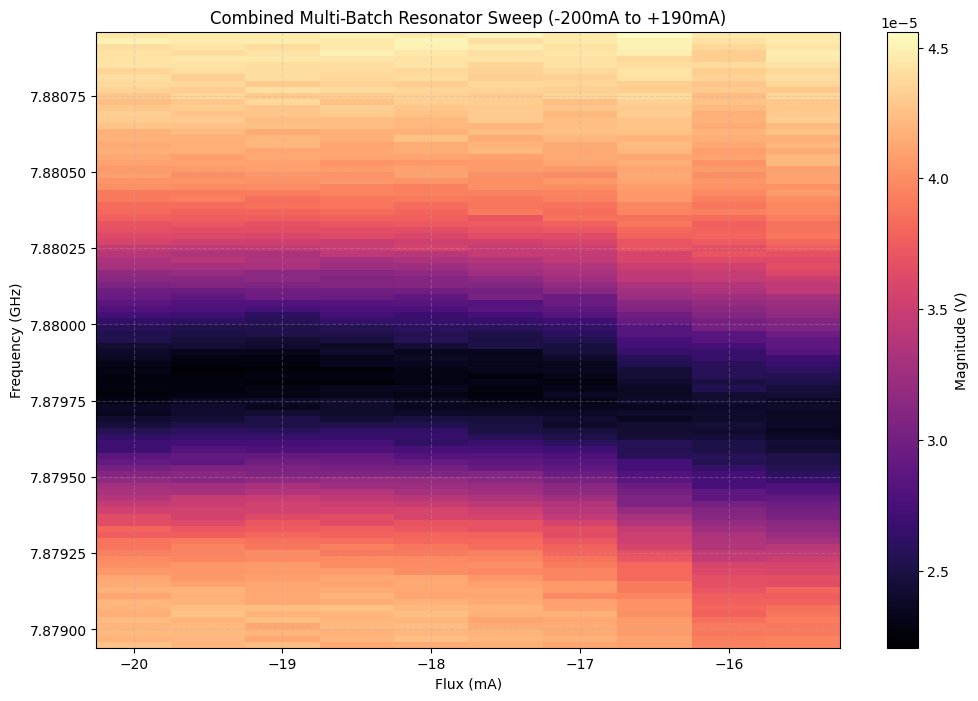

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# --- Define all batches in a list for easy management ---
batches = [
    {
        "folder": "C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-06-10/",
        "time": ((18, 45), (18, 59)),
        "flux": np.linspace(start=-20e-3, stop=0e-3, num=41)[0:10] #np.arange(0e-3, 100e-3 + 10e-3, 10e-3)
        # flux_values = np.linspace(start=-10e-3, stop=10e-3, num=21)
    },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 35), (16, 40)),
    #     "flux": np.arange(-100e-3, -200e-3 - 10e-3, -10e-3)
    # },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 49), (17, 2)),
    #     "flux": np.arange(0e-3, 190e-3 + 5e-3, 5e-3)
    # }
]

def get_filtered_files(folder, start_t, end_t):
    if not os.path.exists(folder):
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) 
             if f.endswith(".hdf5") and "RRSpec" in f]
    
    def extract_t(fname):
        parts = os.path.basename(fname).split("-")
        return (int(parts[0]), int(parts[1]))

    # Filter and Sort by time to match the flux sequence recorded
    filtered = [f for f in files if end_t >= extract_t(f) >= start_t]
    filtered.sort() 
    return filtered

# 1. Collect all data pairs (Flux, Filename) across all batches
all_data_pairs = []

for b in batches:
    files = get_filtered_files(b["folder"], b["time"][0], b["time"][1])
    for i, f in enumerate(files):
        if i < len(b["flux"]):
            all_data_pairs.append((b["flux"][i], f))

# 2. Sort by Flux so the Y-axis is monotonic (e.g., -200mA up to +190mA)
all_data_pairs.sort(key=lambda x: x[0])

# 3. Load Magnitude data
final_flux_axis = []
final_mag_matrix = []
freq_axis = None

print(f"Processing {len(all_data_pairs)} total files...")

for flux, path in all_data_pairs:
    try:
        with h5py.File(path, "r") as f:
            if freq_axis is None:
                lo = 7.88e9+32e6+21e6-0.3e6-2e6-0.6e6-0.15e6 #3.868364e9+50e6-1.443e6 #f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
                freq_axis = (lo + f["resonator_frequency"][()]) / 1e9 # GHz
            
            mag = np.mean(f["Magnitude"][()], axis=0)
            final_mag_matrix.append(mag)
            final_flux_axis.append(flux * 1e3) # mA
    except Exception as e:
        print(f"Skipping {path} due to error: {e}")

# 4. Generate the Heatmap
if final_mag_matrix:
    plt.figure(figsize=(12, 8))
    X, Y = np.meshgrid(freq_axis, final_flux_axis)
    Z = np.array(final_mag_matrix)

    # 'magma' or 'viridis' work well for spectroscopy
    mesh = plt.pcolormesh(Y.T, X.T, Z.T, shading='auto', cmap='magma')
    
    plt.colorbar(mesh, label='Magnitude (V)')
    plt.ylabel('Frequency (GHz)')
    plt.xlabel('Flux (mA)')
    plt.title('Combined Multi-Batch Resonator Sweep (-200mA to +190mA)')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print("No data found to plot!")

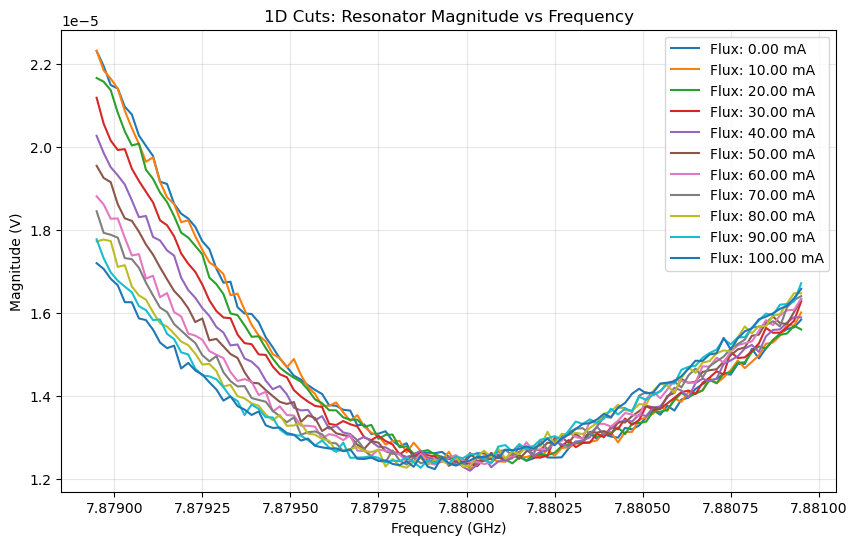

In [6]:
# --- 5. Generate 1D Cuts ---
if final_mag_matrix:
    # Choose the flux values (mA) you want to see a 1D cut for
    # Example: the middle flux, or specific values like 0mA or 50mA
    target_fluxes = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100] # mA
    
    plt.figure(figsize=(10, 6))
    
    for target in target_fluxes:
        # Find the index of the flux value closest to our target
        idx = (np.abs(np.array(final_flux_axis) - target)).argmin()
        actual_flux = final_flux_axis[idx]
        
        # Plot Frequency vs Magnitude for that specific flux row
        plt.plot(freq_axis, final_mag_matrix[idx], label=f"Flux: {actual_flux:.2f} mA")

    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Magnitude (V)')
    plt.title('1D Cuts: Resonator Magnitude vs Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Processing 22 total files...


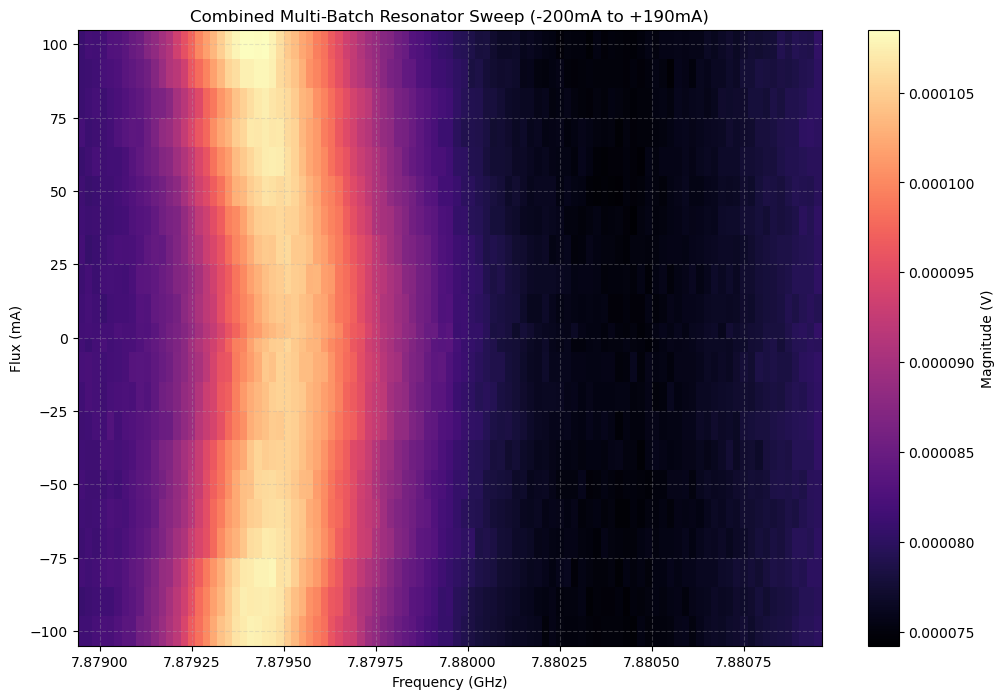

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# --- Define all batches in a list for easy management ---
batches = [
    {
        "folder": "C:/Users/qcrew2/Documents/Candace/eunice/data/2026-03-12/",
        "time": ((21, 4), (21, 10)),
        "flux": np.arange(0e-3, 100e-3 + 10e-3, 10e-3)
    },
    {
        "folder": "C:/Users/qcrew2/Documents/Candace/eunice/data/2026-03-12/",
        "time": ((21, 14), (21, 20)),
        "flux": np.arange(0e-3, -100e-3 - 10e-3, -10e-3)
    },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 49), (17, 2)),
    #     "flux": np.arange(0e-3, 190e-3 + 5e-3, 5e-3)
    # }
]

def get_filtered_files(folder, start_t, end_t):
    if not os.path.exists(folder):
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) 
             if f.endswith(".hdf5") and "RRSpec" in f]
    
    def extract_t(fname):
        parts = os.path.basename(fname).split("-")
        return (int(parts[0]), int(parts[1]))

    # Filter and Sort by time to match the flux sequence recorded
    filtered = [f for f in files if end_t >= extract_t(f) >= start_t]
    filtered.sort() 
    return filtered

# 1. Collect all data pairs (Flux, Filename) across all batches
all_data_pairs = []

for b in batches:
    files = get_filtered_files(b["folder"], b["time"][0], b["time"][1])
    for i, f in enumerate(files):
        if i < len(b["flux"]):
            all_data_pairs.append((b["flux"][i], f))

# 2. Sort by Flux so the Y-axis is monotonic (e.g., -200mA up to +190mA)
all_data_pairs.sort(key=lambda x: x[0])

# 3. Load Magnitude data
final_flux_axis = []
final_mag_matrix = []
freq_axis = None

print(f"Processing {len(all_data_pairs)} total files...")

for flux, path in all_data_pairs:
    try:
        with h5py.File(path, "r") as f:
            if freq_axis is None:
                lo = 7.88e9+32e6+21e6-0.3e6-2e6-0.6e6-0.15e6 #3.868364e9+50e6-1.443e6 #f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
                freq_axis = (lo + f["resonator_frequency"][()]) / 1e9 # GHz
            
            mag = np.mean(f["Magnitude"][()], axis=0)
            final_mag_matrix.append(mag)
            final_flux_axis.append(flux * 1e3) # mA
    except Exception as e:
        print(f"Skipping {path} due to error: {e}")

# 4. Generate the Heatmap
if final_mag_matrix:
    plt.figure(figsize=(12, 8))
    X, Y = np.meshgrid(freq_axis, final_flux_axis)
    Z = np.array(final_mag_matrix)

    # 'magma' or 'viridis' work well for spectroscopy
    mesh = plt.pcolormesh(X, Y, Z, shading='auto', cmap='magma')
    
    plt.colorbar(mesh, label='Magnitude (V)')
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Flux (mA)')
    plt.title('Combined Multi-Batch Resonator Sweep (-200mA to +190mA)')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print("No data found to plot!")

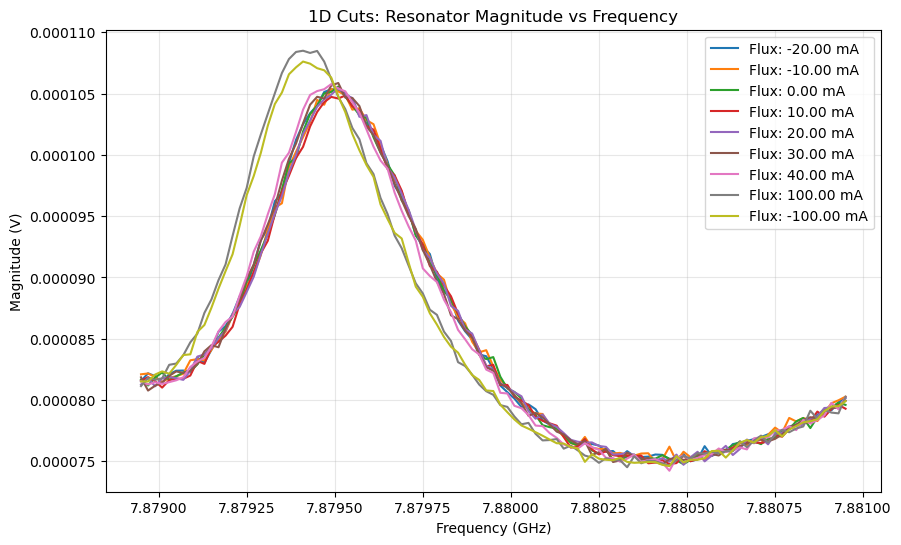

In [12]:
# --- 5. Generate 1D Cuts ---
if final_mag_matrix:
    # Choose the flux values (mA) you want to see a 1D cut for
    # Example: the middle flux, or specific values like 0mA or 50mA
    target_fluxes = [-20, -10, 0, 10, 20, 30, 40, 100,-100]#np.arange(-100, 100,10) #[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100] # mA
    
    plt.figure(figsize=(10, 6))
    
    for target in target_fluxes:
        # Find the index of the flux value closest to our target
        idx = (np.abs(np.array(final_flux_axis) - target)).argmin()
        actual_flux = final_flux_axis[idx]
        
        # Plot Frequency vs Magnitude for that specific flux row
        plt.plot(freq_axis, final_mag_matrix[idx], label=f"Flux: {actual_flux:.2f} mA")

    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Magnitude (V)')
    plt.title('1D Cuts: Resonator Magnitude vs Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Processing 32 total files...


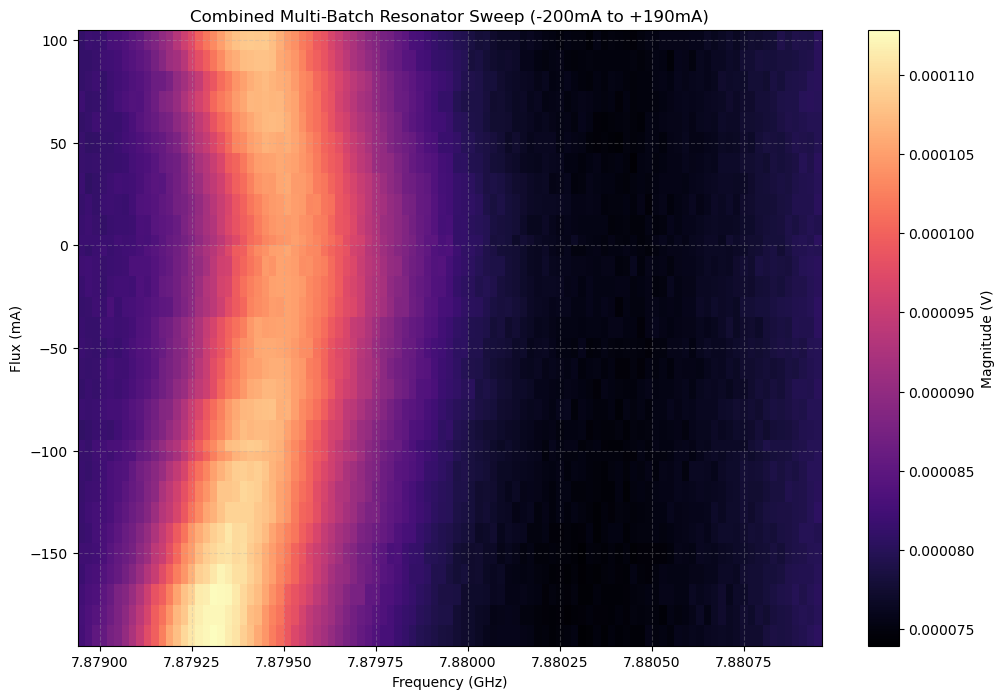

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# --- Define all batches in a list for easy management ---
batches = [
    {
        "folder": "C:/Users/qcrew2/Documents/Candace/eunice/data/2026-03-12/",
        "time": ((21, 4), (21, 10)),
        "flux": np.arange(0e-3, 100e-3 + 10e-3, 10e-3)
    },
    {
        "folder": "C:/Users/qcrew2/Documents/Candace/eunice/data/2026-03-12/",
        "time": ((21, 14), (21, 20)),
        "flux": np.arange(0e-3, -100e-3 - 10e-3, -10e-3)
    },
        {
        "folder": "C:/Users/qcrew2/Documents/Candace/eunice/data/2026-03-12/",
        "time": ((21, 29), (21, 35)),
        "flux": np.arange(-100e-3, -190e-3 - 10e-3, -10e-3)
    },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 35), (16, 40)),
    #     "flux": np.arange(-100e-3, -200e-3 - 10e-3, -10e-3)
    # },
    # {
    #     "folder": "C:/Users/qcrew/Documents/eunice/data/2026-02-25/",
    #     "time": ((16, 49), (17, 2)),
    #     "flux": np.arange(0e-3, 190e-3 + 5e-3, 5e-3)
    # }
]

def get_filtered_files(folder, start_t, end_t):
    if not os.path.exists(folder):
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) 
             if f.endswith(".hdf5") and "RRSpec" in f]
    
    def extract_t(fname):
        parts = os.path.basename(fname).split("-")
        return (int(parts[0]), int(parts[1]))

    # Filter and Sort by time to match the flux sequence recorded
    filtered = [f for f in files if end_t >= extract_t(f) >= start_t]
    filtered.sort() 
    return filtered

# 1. Collect all data pairs (Flux, Filename) across all batches
all_data_pairs = []

for b in batches:
    files = get_filtered_files(b["folder"], b["time"][0], b["time"][1])
    for i, f in enumerate(files):
        if i < len(b["flux"]):
            all_data_pairs.append((b["flux"][i], f))

# 2. Sort by Flux so the Y-axis is monotonic (e.g., -200mA up to +190mA)
all_data_pairs.sort(key=lambda x: x[0])

# 3. Load Magnitude data
final_flux_axis = []
final_mag_matrix = []
freq_axis = None

print(f"Processing {len(all_data_pairs)} total files...")

for flux, path in all_data_pairs:
    try:
        with h5py.File(path, "r") as f:
            if freq_axis is None:
                lo = 7.88e9+32e6+21e6-0.3e6-2e6-0.6e6-0.15e6 #3.868364e9+50e6-1.443e6 #f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
                freq_axis = (lo + f["resonator_frequency"][()]) / 1e9 # GHz
            
            mag = np.mean(f["Magnitude"][()], axis=0)
            final_mag_matrix.append(mag)
            final_flux_axis.append(flux * 1e3) # mA
    except Exception as e:
        print(f"Skipping {path} due to error: {e}")

# 4. Generate the Heatmap
if final_mag_matrix:
    plt.figure(figsize=(12, 8))
    X, Y = np.meshgrid(freq_axis, final_flux_axis)
    Z = np.array(final_mag_matrix)

    # 'magma' or 'viridis' work well for spectroscopy
    mesh = plt.pcolormesh(X, Y, Z, shading='auto', cmap='magma')
    
    plt.colorbar(mesh, label='Magnitude (V)')
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Flux (mA)')
    plt.title('Combined Multi-Batch Resonator Sweep (-200mA to +190mA)')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print("No data found to plot!")

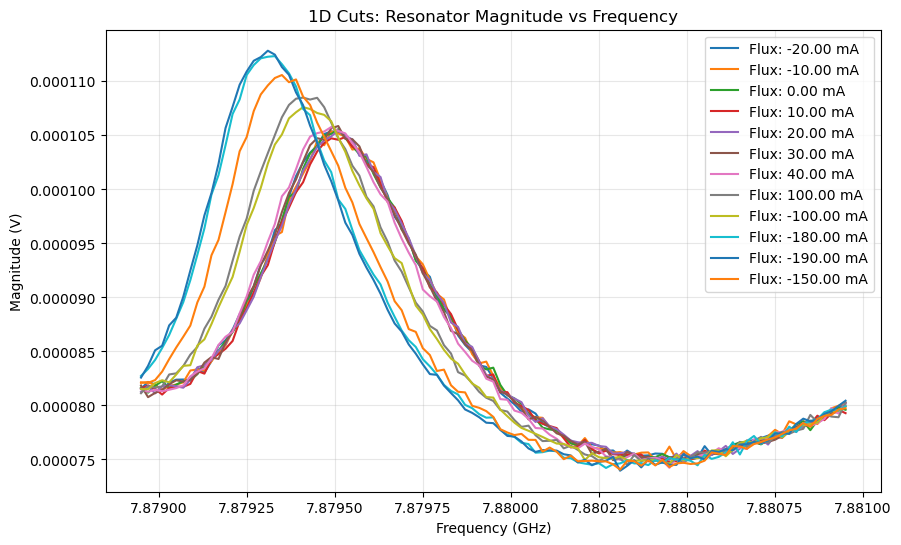

In [17]:
# --- 5. Generate 1D Cuts ---
if final_mag_matrix:
    # Choose the flux values (mA) you want to see a 1D cut for
    # Example: the middle flux, or specific values like 0mA or 50mA
    target_fluxes = [-20, -10, 0, 10, 20, 30, 40, 100,-100, -180,-190, -150]#np.arange(-100, 100,10) #[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100] # mA
    
    plt.figure(figsize=(10, 6))
    
    for target in target_fluxes:
        # Find the index of the flux value closest to our target
        idx = (np.abs(np.array(final_flux_axis) - target)).argmin()
        actual_flux = final_flux_axis[idx]
        
        # Plot Frequency vs Magnitude for that specific flux row
        plt.plot(freq_axis, final_mag_matrix[idx], label=f"Flux: {actual_flux:.2f} mA")

    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Magnitude (V)')
    plt.title('1D Cuts: Resonator Magnitude vs Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [19]:
# Define the filename
save_path = "combined_flux_sweep_20260312_SNAILRM_rr_R.npz"

# Save arrays
# We use keyword arguments so we can load them back easily by name
np.savez(
    save_path, 
    frequency_ghz=freq_axis, 
    flux_ma=np.array(final_flux_axis), 
    magnitude=np.array(final_mag_matrix)
)

print(f"Data successfully saved to {save_path}")

Data successfully saved to combined_flux_sweep_20260312_SNAILRM_rr_R.npz


Number of files selected: 11


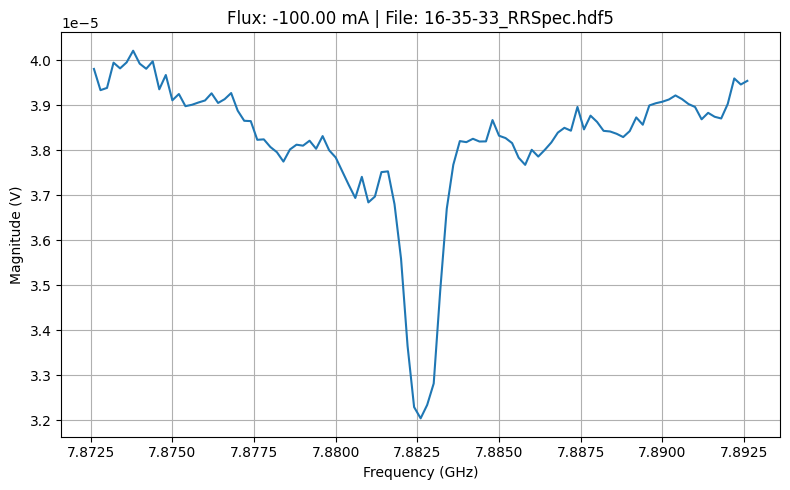

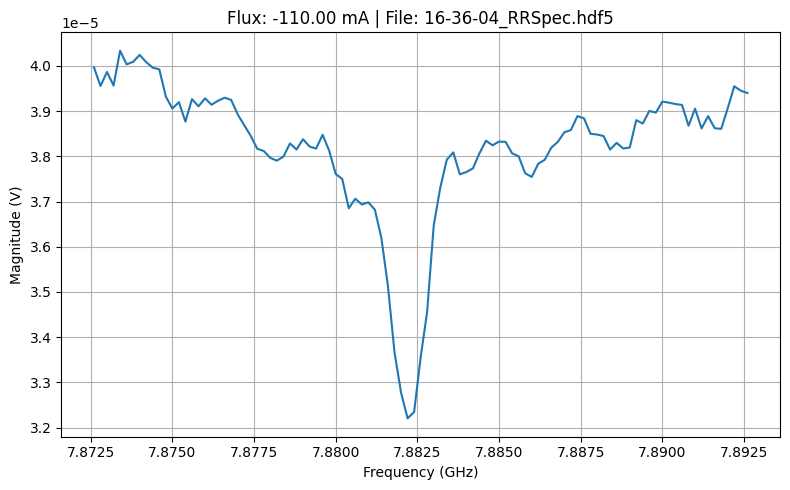

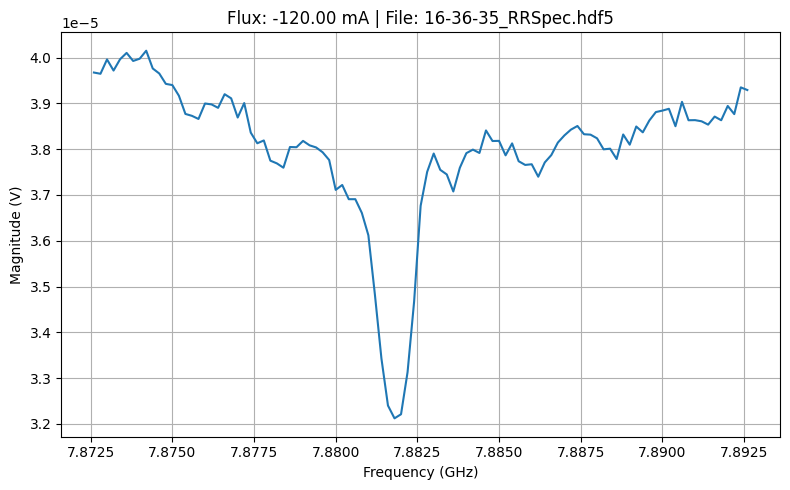

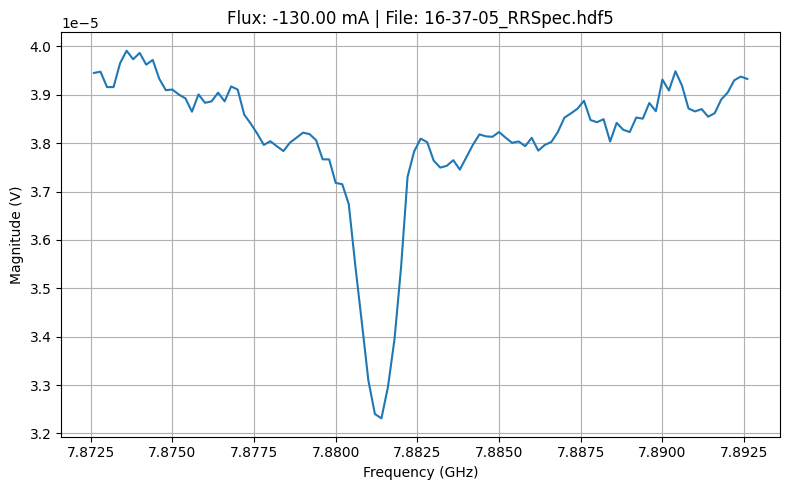

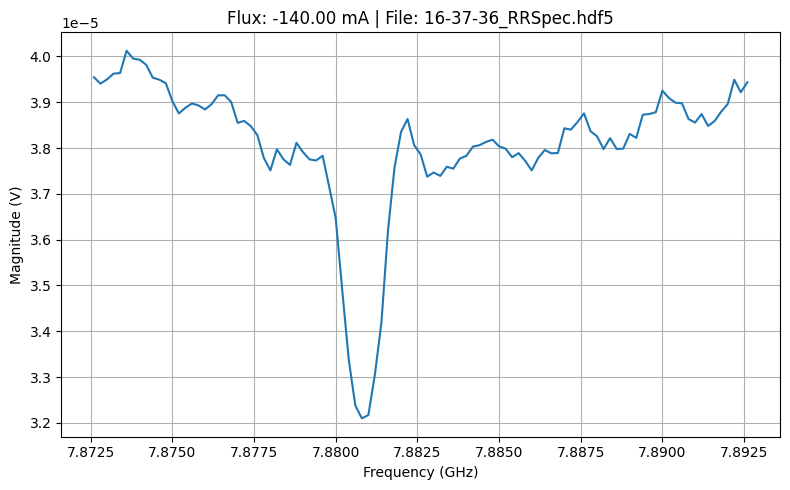

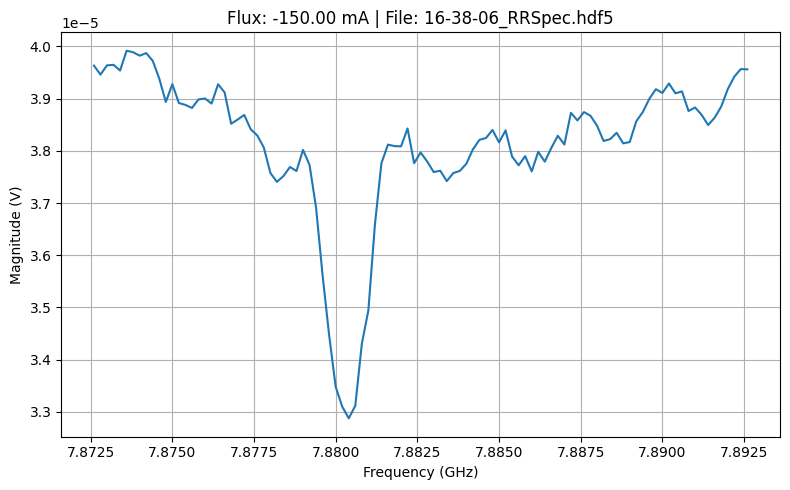

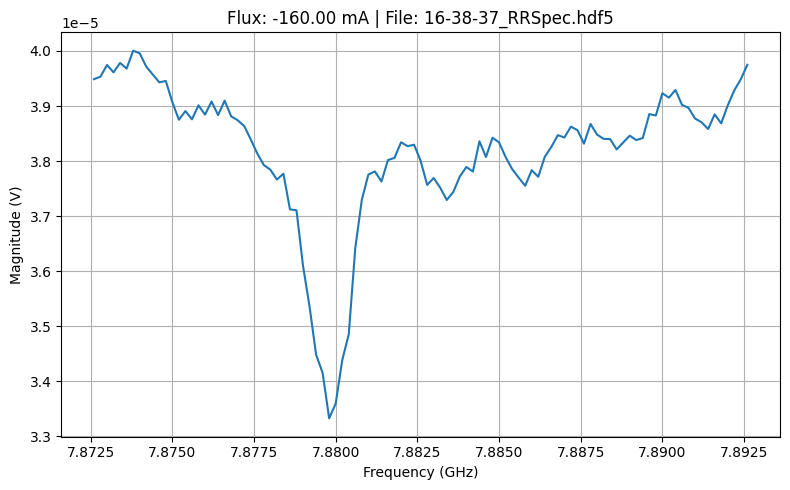

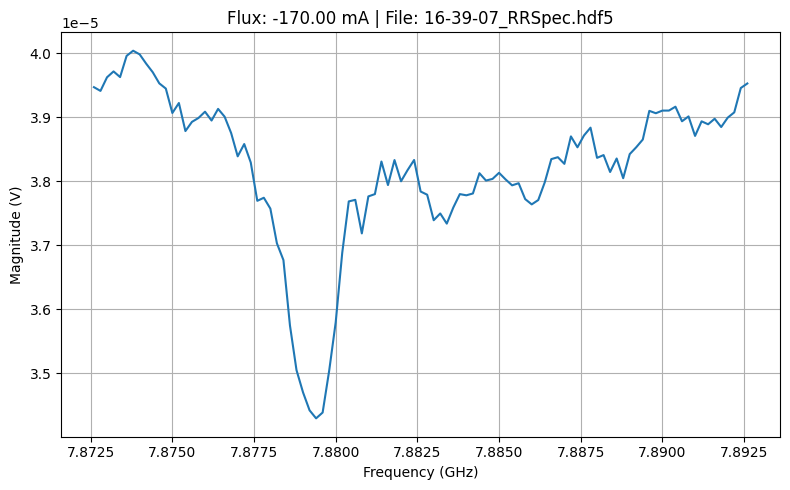

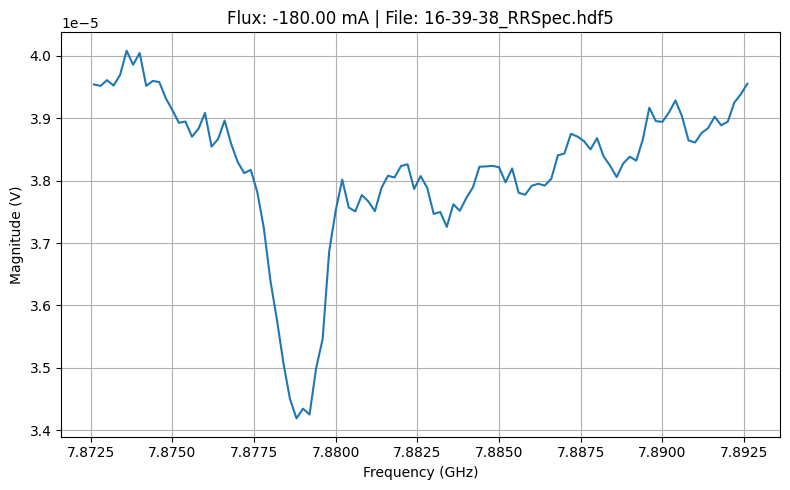

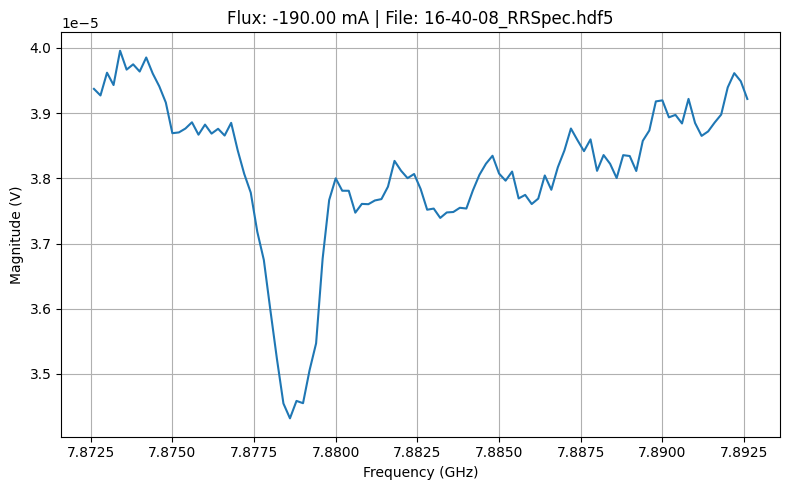

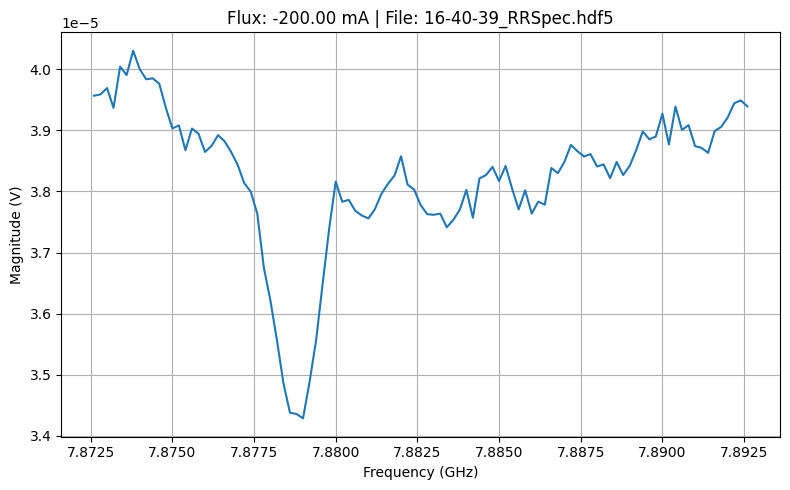

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# Define folder paths
# _folder_0 = "C:/Users/qcrew/Documents/eunice/data/2026-02-25/"
# filter_time_0 = (16, 15)
# filter_time_0_end = (16, 21)
_folder_0 = "C:/Users/qcrew/Documents/eunice/data/2026-02-25/"
filter_time_0 = (16, 35)
filter_time_0_end = (16, 40)

def extract_time(filename):
    """Extracts (hour, minute) from the filename."""
    try:
        parts = filename.split("-")
        hour, minute = int(parts[0]), int(parts[1])
        return hour, minute
    except (ValueError, IndexError):
        return (-1, -1)

def process_folder(folder_path, start_t, end_t):
    """Processes files in the folder and returns filtered full paths."""
    local_filenames = []
    if not os.path.exists(folder_path):
        print(f"Error: Folder '{folder_path}' does not exist!")
        return local_filenames

    for _filename in os.listdir(folder_path):
        if _filename.endswith(".hdf5") and "RRSpec" in _filename:
            time = extract_time(_filename)
            if time != (-1, -1) and end_t >= time >= start_t:
                local_filenames.append(os.path.join(folder_path, _filename))
    
    # Sort filenames to ensure they match the order of your flux_points
    local_filenames.sort()
    return local_filenames

# Process folder
grouped_filenames = process_folder(_folder_0, filter_time_0, filter_time_0_end)
print(f"Number of files selected: {len(grouped_filenames)}")

# Define Flux Range
# flux_start, flux_end, flux_step = -100e-3, 0e-3, 5e-3
# flux_points = np.arange(flux_start, flux_end + flux_step, flux_step)

flux_start = -100e-3
flux_end = -200e-3
flux_step = -10e-3
flux_points = np.arange(flux_start, flux_end+flux_step, flux_step)
freqs, mag_data = [], []

for index, filename in enumerate(grouped_filenames):
    if index >= len(flux_points):
        print("Warning: More files found than flux points defined.")
        break

    with h5py.File(filename, "r") as f:
        # Extract data
        freqs_values = f["resonator_frequency"][()]
        # Averaging over the first axis (assuming pulse/repetition axis)
        MAG_values = np.mean(f["Magnitude"][()], axis=0) 
        
        # Attempt to get lo_freq from attributes if not defined globally
        # Adjust the key path based on your specific HDF5 structure
        lo_freq = 7.88e9+32e6+21e6-0.3e6+0.1e6-0.3e6+0.1e6 #f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
        
        full_freqs = lo_freq + freqs_values

        # Store data
        freqs.append(full_freqs)
        mag_data.append(MAG_values)

        # Plotting
        plt.figure(figsize=(8, 5))
        plt.plot(full_freqs / 1e9, MAG_values, label='Magnitude') # Freq in GHz for readability
        plt.xlabel('Frequency (GHz)')
        plt.ylabel('Magnitude (V)')
        plt.title(f'Flux: {flux_points[index]*1e3:.2f} mA | File: {os.path.basename(filename)}')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

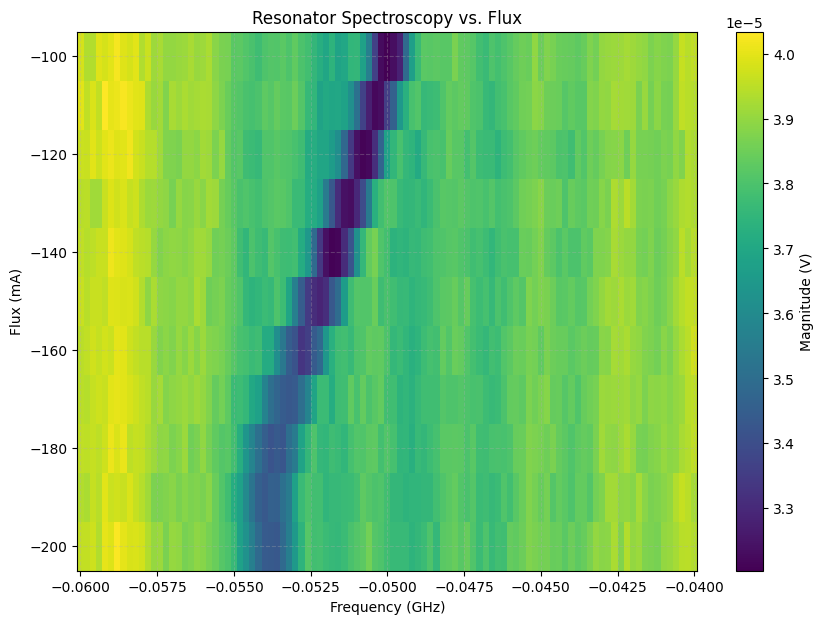

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

# ... (Include your extract_time and process_folder functions here) ...

# 1. Collect Data into lists
all_mags = []
selected_flux = []

for index, filename in enumerate(grouped_filenames):
    if index >= len(flux_points): break
    
    with h5py.File(filename, "r") as f:
        # Get frequency once (assuming it's the same for all files)
        if index == 0:
            lo_freq = f["instruments/lo_rr"].attrs["frequency"] if "instruments/lo_rr" in f else 0
            freq_axis = (lo_freq + f["resonator_frequency"][()]) / 1e9  # Convert to GHz
        
        mag_slice = np.mean(f["Magnitude"][()], axis=0)
        all_mags.append(mag_slice)
        selected_flux.append(flux_points[index] * 1e3) # Convert to mA for plotting

# 2. Convert to 2D numpy array (Rows: Flux, Columns: Frequency)
Z = np.array(all_mags)
X, Y = np.meshgrid(freq_axis, selected_flux)

# 3. Plotting
plt.figure(figsize=(10, 7))
# 'shading="nearest"' or "auto" ensures the grid aligns with your data points
mesh = plt.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')

# Add a colorbar to show magnitude scale
cbar = plt.colorbar(mesh)
cbar.set_label('Magnitude (V)')

plt.xlabel('Frequency (GHz)')
plt.ylabel('Flux (mA)')
plt.title('Resonator Spectroscopy vs. Flux')
plt.grid(True, alpha=0.3, linestyle='--')

plt.show()

## 2D PLOT 

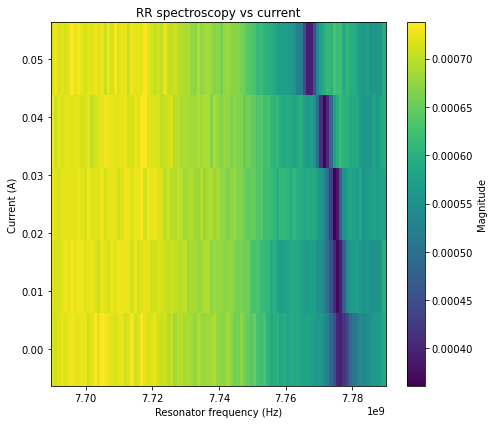

In [5]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt

freqs = None
currents = []
mag_2d = []
phase_2d = []

for filename in grouped_filenames:
    with h5py.File(filename, "r") as f:
        freqs_values = f["resonator_frequency"][()]      # (N_freq,)
        MAG_values   = np.mean(f["Magnitude"][()], axis=0)
        PHASE_values = np.mean(f["Phase"][()], axis=0)
        current      = f["instruments/yoko2"].attrs["current"]
        freqs_values = lo_freq + freqs_values
        if freqs is None:
            freqs = freqs_values
        else:
            # safety check: same frequency grid
            if not np.allclose(freqs, freqs_values):
                raise ValueError("Frequency grids do not match!")

        currents.append(current)
        mag_2d.append(MAG_values)
        phase_2d.append(PHASE_values)
currents = np.array(currents)
mag_2d   = np.array(mag_2d)
phase_2d = np.array(phase_2d)

# sort by current
order = np.argsort(currents)
currents = currents[order]
mag_2d   = mag_2d[order]
phase_2d = phase_2d[order]

plt.figure(figsize=(7, 6))

plt.pcolormesh(
    freqs,
    currents,
    mag_2d,
    shading="auto",
    cmap="viridis"
)

plt.xlabel("Resonator frequency (Hz)")
plt.ylabel("Current (A)")
plt.title("RR spectroscopy vs current")
plt.colorbar(label="Magnitude")

plt.tight_layout()
plt.show()


In [5]:
    # Save data as NPZ
min_current = np.min(currents)
max_current = np.max(currents)
save_name = f"20260210_siderm_rr_flux_sweep{min_current}to{max_current}_2.npz"
np.savez(
save_name,
freq_GHz=freqs,
current_uA=currents,
y_amp_dBfit=mag_2d,
)
print(f"Saved data to {save_name}")

Saved data to 20260210_siderm_rr_flux_sweep-0.15to0.15_2.npz


In [7]:
freqs.shape

(101,)

In [8]:
currents.shape

(31,)

In [9]:
mag_2d.shape

(31, 101)